<a href="https://colab.research.google.com/github/baotam27/DeepLearning/blob/main/Tuan4_Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Thực hành AutoEncoder

2.1 Nạp thư viên

In [2]:
from keras.datasets import mnist
import numpy as np
import keras
from keras import layers

2.2 Nạp data

In [4]:
(x_train,_),(x_test,_)=mnist.load_data()
x_train=x_train.astype('float32')/255.
x_test=x_test.astype('float32')/255.
x_train=x_train.reshape((len(x_train),np.prod(x_train.shape[1:])))
x_test=x_test.reshape((len(x_test),np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)
(10000, 784)


2.3 Xây dựng mô hình Autoencoder

In [5]:
#This is the size of our encoded representations
encoding_dim=32 #32 floats -> compression of factor 24.5, assuming the input is 784 floats

#This is our input image
input_img=keras.Input(shape=(784,))
#"encoded" is the encoded representation of the input
encoded=layers.Dense(encoding_dim, activation='relu')(input_img)
#"decoded" is the lossy reconstruction of the input
decoded=layers.Dense(784, activation='sigmoid')(encoded)

#This model maps an input to its reconstruction
autoencoder=keras.Model(input_img, decoded)

#This model maps an input to its encoded representation
encoder=keras.Model(input_img, encoded)
#This model maps an input to its encoded representation
encoder_input=keras.Input(shape=(encoding_dim,))
#Retrieve the last layer of the autoencoder model
decoder_layer=autoencoder.layers[-1]
#Create the decoder model
decoder=keras.Model(encoder_input, decoder_layer(encoder_input))

2.4 Huấn luyện mô hình

In [6]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256, verbose=1,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0117 - loss: 0.2759 - val_accuracy: 0.0096 - val_loss: 0.1882
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0102 - loss: 0.1701 - val_accuracy: 0.0099 - val_loss: 0.1531
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.0100 - loss: 0.1440 - val_accuracy: 0.0106 - val_loss: 0.1333
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0107 - loss: 0.1281 - val_accuracy: 0.0106 - val_loss: 0.1211
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0114 - loss: 0.1181 - val_accuracy: 0.0118 - val_loss: 0.1133
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0122 - loss: 0.1114 - val_accuracy: 0.0125 - val_loss: 0.1075
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.0132 - loss: 0.1064 - val_accuracy: 0.0120 - val_loss: 0.1031
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0128 - loss: 0.1027 - val_accu

2.5 Dự báo loại ảnh sử dụng Autoencoder

In [7]:
encoded_imgs=encoder.predict(x_test)
decoded_imgs=decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


2.6 Hiển thị ảnh từ môi hình Autoencoder

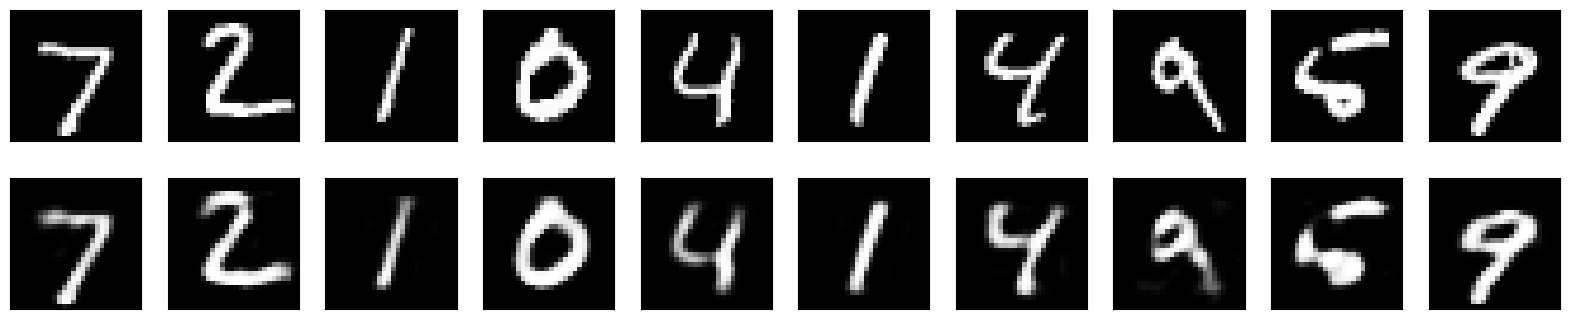

In [8]:
#Use Matplotlib (don't ask)
import matplotlib.pyplot as plt

n=10 #How many digits we will display
plt.figure(figsize=(20,4))
for i in range(n):
    #Display original
    ax=plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    #Display reconstruction
    ax=plt.subplot(2,n,i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

3. Cải tiến AutoEncoder

3.1 Thêm L1

In [9]:
#This is the size of our encoded representations
encoding_dim = 32 #32 floats -> compression of factor 24.5, assuming the input is 784 floats

#This is our input image
input_img = keras.Input(shape=(784,))
#"encoded" is the encoded representation of input
encoded = layers.Dense(encoding_dim, activation='relu',
                      activity_regularizer=keras.regularizers.l1(10e-5))(input_img)

#"decoded" is the lossy reconstruction of the input
decoded = layers.Dense(784, activation='sigmoid')(encoded)

#This model maps an input to its reconstruction
autoencoder = keras.Model(input_img, decoded)

#This model maps an input to its reconstruction
encoder = keras.Model(input_img, encoded)
#This is our encoded (32-dimensional)input
encoder_input = keras.Input(shape=(encoding_dim,))
#Retrieve the last layer of the autoencoder model
decoder_layer = autoencoder.layers[-1]
#Create the decoder model
decoder = keras.Model(encoder_input, decoder_layer(encoder_input))

In [10]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256, verbose=1,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0145 - loss: 0.6550 - val_accuracy: 0.0161 - val_loss: 0.6155
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0150 - loss: 0.5832 - val_accuracy: 0.0161 - val_loss: 0.5535
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.0150 - loss: 0.5275 - val_accuracy: 0.0161 - val_loss: 0.5038
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0150 - loss: 0.4827 - val_accuracy: 0.0161 - val_loss: 0.4638
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0150 - loss: 0.4466 - val_accuracy: 0.0161 - val_loss: 0.4314
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0150 - loss: 0.4174 - val_accuracy: 0.0161 - val_loss: 0.4050
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0150 - loss: 0.3935 - val_accuracy: 0.0161 - val_loss: 0.3834
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0150 - loss: 0.3739 - val_accu

3.2 Thêm layers

In [14]:
# This is the size of our encoded representations
encoding_dim = 32 # 32 floats -> compression of factor 24.5, assuming the input is 784 floats

# method 2:increasing multi-layers

# This is our input image
input_img = keras.Input(shape=(784,))
# "encoded" is the encoded representation of the input
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)
# "decoded" is the lossy reconstruction of the input

# SUA 1: Thay vi goi (decoded), ta phai truyen bien (encoded) o dong tren vao day de tiep tuc chuoi hoat dong
decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

# This model maps an input to its reconstruction
autoencoder = keras.Model(input_img, decoded)

# This model map an input to its encoded representation
# SUA 2: Encoder thi dau ra phai la lop nén o giua (autoencoder.layers[3]), chu khong phai 'decoded'
encoder = keras.Model(input_img, autoencoder.layers[3].output)

# This model maps an input to its encoded representaion
# (Dong nay trong code cu cua ban bi trung lap lai doan tren nen minh giu nguyen de gop chung luong)
encoded_input = keras.Input(shape=(32,))

# Retrieve the last layer of the autoencoder model
# SUA 3: Vi ban dung tang cuong nhieu lop (Method 2), phan decoder phai lay tu 3 lop cuoi cung cua autoencoder chu khong chi lay moi lop [-1]
decoder_layer1 = autoencoder.layers[-3]
decoder_layer2 = autoencoder.layers[-2]
decoder_layer3 = autoencoder.layers[-1]

# Create the decoder model
# SUA 4: Ket noi thong suon tu encoded_input (32) di qua day du 3 lop giai ma de ra lai anh phang (784)
decoder_output = decoder_layer3(decoder_layer2(decoder_layer1(encoded_input)))
decoder = keras.Model(encoded_input, decoder_output)